# Spatial & Regional Analysis — 50 Indian Cities

This Kaggle notebook follows the reference analysis flow while adapting it to 50 cities across India. It creates a city profile, checks coverage, maps weather variables, compares regions, validates spatial trends, and identifies anomalous or insufficient cities.

Dataset: https://www.kaggle.com/datasets/mukeshdevrath007/indian-5000-cities-weather-data

In [1]:
import os
import re
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

SAVE = "/kaggle/working/spatial_regional_50_cities/"
os.makedirs(SAVE, exist_ok=True)

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
REGION_ORDER = ["North", "Northeast", "East", "Central", "West", "South"]
REGION_COLORS = {
    "North": "#4e8ef7", "Northeast": "#56d98e", "East": "#4ec9f7",
    "Central": "#f7c948", "West": "#f7914e", "South": "#f76e6e",
    "Unknown": "#999999",
}

print("Setup complete")

Setup complete


## Step 1 — Find dataset files and coordinate metadata

In [2]:
INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise FileNotFoundError("Run this notebook inside Kaggle.")

all_csv_files = sorted([
    str(file) for file in INPUT_ROOT.rglob("*")
    if file.is_file() and (
        file.name.lower().endswith(".csv") or
        file.name.lower().endswith(".csv.gz")
    )
])

if not all_csv_files:
    raise FileNotFoundError(
        "No CSV files found. Attach the Kaggle weather dataset using Add Input."
    )

print(f"Total CSV files found: {len(all_csv_files):,}")
print("First CSV file:", all_csv_files[0])

Total CSV files found: 4,686
First CSV file: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv


In [3]:
def normalize_name(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def find_column(columns, possible_names):
    normalized = {column: normalize_name(column) for column in columns}
    targets = [normalize_name(name) for name in possible_names]

    exact = [column for column, name in normalized.items() if name in targets]
    if exact:
        return exact[0]

    partial = [column for column, name in normalized.items()
               if any(target in name for target in targets)]
    return partial[0] if partial else None


# Search weather.csv first, then other likely metadata filenames.
likely_metadata = sorted(
    all_csv_files,
    key=lambda file: (
        0 if Path(file).name.lower() == "weather.csv" else
        1 if any(word in Path(file).name.lower()
                 for word in ["city", "cities", "location", "metadata"]) else 2,
        os.path.getsize(file),
    )
)

metadata_file = None
metadata_mapping = None

for file in likely_metadata:
    filename = Path(file).name.lower()
    if not (filename == "weather.csv" or
            any(word in filename for word in ["city", "cities", "location", "metadata"])):
        continue

    try:
        columns = pd.read_csv(file, nrows=0).columns.tolist()
        mapping = {
            "city": find_column(columns, ["city", "city_name", "name", "location"]),
            "latitude": find_column(columns, ["latitude", "lat"]),
            "longitude": find_column(columns, ["longitude", "lon", "lng"]),
            "state": find_column(columns, ["state", "state_name", "admin_name", "admin"]),
            "elevation": find_column(columns, ["elevation", "altitude"]),
        }
        if mapping["city"] and mapping["latitude"] and mapping["longitude"]:
            metadata_file = file
            metadata_mapping = mapping
            break
    except Exception:
        continue

if metadata_file is None:
    raise FileNotFoundError(
        "Could not find the city metadata CSV containing city, latitude and longitude."
    )

print("Coordinate metadata file:", metadata_file)
print("Detected metadata columns:", metadata_mapping)

Coordinate metadata file: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv
Detected metadata columns: {'city': 'city', 'latitude': 'lat', 'longitude': 'lng', 'state': None, 'elevation': None}


In [5]:
metadata_usecols = [column for column in metadata_mapping.values() if column is not None]
city_metadata = pd.read_csv(metadata_file, usecols=metadata_usecols, low_memory=False)

rename_metadata = {
    metadata_mapping["city"]: "metadata_city",
    metadata_mapping["latitude"]: "latitude",
    metadata_mapping["longitude"]: "longitude",
}
if metadata_mapping["state"]:
    rename_metadata[metadata_mapping["state"]] = "state"
if metadata_mapping["elevation"]:
    rename_metadata[metadata_mapping["elevation"]] = "elevation"

city_metadata = city_metadata.rename(columns=rename_metadata)
city_metadata["city_key"] = city_metadata["metadata_city"].apply(normalize_name)
city_metadata["latitude"] = pd.to_numeric(city_metadata["latitude"], errors="coerce")
city_metadata["longitude"] = pd.to_numeric(city_metadata["longitude"], errors="coerce")

if "elevation" not in city_metadata:
    city_metadata["elevation"] = np.nan
else:
    city_metadata["elevation"] = pd.to_numeric(city_metadata["elevation"], errors="coerce")
if "state" not in city_metadata:
    city_metadata["state"] = np.nan

city_metadata = city_metadata.drop_duplicates("city_key")
city_metadata = city_metadata[
    city_metadata["latitude"].between(6, 38) &
    city_metadata["longitude"].between(68, 98)
].copy()

print("Valid Indian city coordinates:", len(city_metadata))
display(city_metadata.head())

Valid Indian city coordinates: 5584


,metadata_city,latitude,longitude,city_key,elevation,state
0,Delhi,28.61,77.23,delhi,NaN,NaN
1,Mumbai,19.08,72.88,mumbai,NaN,NaN
2,Kolkata,22.57,88.37,kolkata,NaN,NaN
3,Bangalore,12.98,77.59,bangalore,NaN,NaN
4,Chennai,13.08,80.28,chennai,NaN,NaN


## Step 2 — Select the same 50-city sample using valid metadata

In [6]:
def get_city_from_filename(file_path):
    path = Path(file_path)
    name = path.name[:-7] if path.name.lower().endswith(".csv.gz") else path.stem
    generic = {"weather", "weatherdata", "hourlyweather", "data"}
    return path.parent.name if normalize_name(name) in generic else name


# The metadata file must not be treated as an hourly city file.
city_csv_files = [file for file in all_csv_files if file != metadata_file]
available_files = pd.DataFrame({
    "city": [get_city_from_filename(file) for file in city_csv_files],
    "file": city_csv_files,
})
available_files["city_key"] = available_files["city"].apply(normalize_name)

invalid_words = ["weatherdata", "scraping", "analysis", "readme", "metadata"]
available_files = available_files[
    ~available_files["city_key"].apply(
        lambda name: any(word in name for word in invalid_words)
    )
].drop_duplicates("city_key")

# Keep only files that have an exact coordinate record in the metadata CSV.
available_files = available_files.merge(
    city_metadata[["city_key", "metadata_city", "latitude", "longitude", "state", "elevation"]],
    on="city_key", how="inner"
)

PREFERRED_CITIES = [
    "Agartala", "Agra", "Ahmedabad", "Aizawl", "Amritsar",
    "Bhopal", "Chandigarh", "Chennai", "Coimbatore", "Cuttack",
    "Dehra Dun", "Delhi", "Guwahati", "Hyderabad", "Imphal",
    "Indore", "Itanagar", "Jaipur", "Jammu", "Jodhpur",
    "Kochi", "Kohima", "Kolkata", "Kota", "Leh",
    "Lucknow", "Ludhiana", "Mumbai", "Nagpur", "Patna",
    "Prayagraj", "Pune", "Raipur", "Rajkot", "Ranchi"
]
preferred_keys = {normalize_name(city) for city in PREFERRED_CITIES}
preferred = available_files[available_files["city_key"].isin(preferred_keys)]
remaining = available_files[~available_files["city_key"].isin(preferred["city_key"])].sort_values("city").reset_index(drop=True)

needed = 50 - len(preferred)
if needed < 0:
    selected_files = preferred.head(50).copy()
else:
    indices = np.linspace(0, len(remaining) - 1, needed, dtype=int)
    selected_files = pd.concat([preferred, remaining.iloc[indices]], ignore_index=True)

selected_files = selected_files.drop_duplicates("city_key").head(50)
if len(selected_files) != 50:
    raise ValueError(f"Only {len(selected_files)} valid coordinate-matched cities were selected.")

print("Selected valid cities:", len(selected_files))
display(selected_files[["city", "state", "latitude", "longitude", "file"]])

Selected valid cities: 50


,city,state,latitude,longitude,file
0,Agartala,NaN,23.83,91.28,/kaggle/input/datasets/mukeshdevrath007/indian...
1,Agra,NaN,27.18,78.02,/kaggle/input/datasets/mukeshdevrath007/indian...
2,Ahmedabad,NaN,23.03,72.58,/kaggle/input/datasets/mukeshdevrath007/indian...
3,Aizawl,NaN,23.73,92.72,/kaggle/input/datasets/mukeshdevrath007/indian...
4,Amritsar,NaN,31.64,74.86,/kaggle/input/datasets/mukeshdevrath007/indian...
5,Bhopal,NaN,23.25,77.42,/kaggle/input/datasets/mukeshdevrath007/indian...
6,Chandigarh,NaN,30.75,76.78,/kaggle/input/datasets/mukeshdevrath007/indian...
7,Chennai,NaN,13.08,80.28,/kaggle/input/datasets/mukeshdevrath007/indian...
8,Coimbatore,NaN,11.02,76.96,/kaggle/input/datasets/mukeshdevrath007/indian...
9,Cuttack,NaN,20.52,85.79,/kaggle/input/datasets/mukeshdevrath007/indian...


## Step 3 — Assign broad Indian regions

In [7]:
STATE_REGION = {
    "jammuandkashmir": "North", "ladakh": "North", "himachalpradesh": "North",
    "punjab": "North", "haryana": "North", "chandigarh": "North",
    "delhi": "North", "uttarakhand": "North", "uttarpradesh": "North",
    "assam": "Northeast", "arunachalpradesh": "Northeast", "manipur": "Northeast",
    "meghalaya": "Northeast", "mizoram": "Northeast", "nagaland": "Northeast",
    "tripura": "Northeast", "sikkim": "Northeast",
    "bihar": "East", "jharkhand": "East", "odisha": "East", "westbengal": "East",
    "madhyapradesh": "Central", "chhattisgarh": "Central",
    "rajasthan": "West", "gujarat": "West", "maharashtra": "West", "goa": "West",
    "andhrapradesh": "South", "telangana": "South", "karnataka": "South",
    "kerala": "South", "tamilnadu": "South", "puducherry": "South",
}


def coordinate_region(latitude, longitude):
    if longitude >= 88 and latitude >= 21:
        return "Northeast"
    if latitude >= 28:
        return "North"
    if longitude <= 76 and latitude >= 15:
        return "West"
    if latitude < 20:
        return "South"
    if longitude >= 84:
        return "East"
    return "Central"


def assign_region(row):
    state_key = normalize_name(row["state"])
    if state_key in STATE_REGION:
        return STATE_REGION[state_key]
    return coordinate_region(row["latitude"], row["longitude"])


selected_files["region"] = selected_files.apply(assign_region, axis=1)
print("Regional distribution:")
display(selected_files["region"].value_counts().reindex(REGION_ORDER).dropna().to_frame("cities"))

Regional distribution:


,cities
region,
North,7
Northeast,8
East,7
Central,11
West,10
South,7


## Step 4 — Build the city profile table

In [8]:
WEATHER_ALIASES = {
    "time": ["time", "datetime", "date"],
    "temperature": ["temperature2m", "temp2m", "temperature"],
    "humidity": ["relativehumidity2m", "humidity2m", "relativehumidity"],
    "dew": ["dewpoint2m", "dewpoint"],
    "precipitation": ["precipitation", "precip", "rain"],
    "cloud": ["cloudcover", "cloudiness"],
    "wind_100m": ["windspeed100m", "wind100m"],
    "wind_10m": ["windspeed10m", "wind10m"],
    "pressure": ["pressuremsl", "sealevelpressure", "surfacepressure"],
}


def match_weather_columns(columns):
    normalized = {column: normalize_name(column) for column in columns}
    matched = {}
    for standard, aliases in WEATHER_ALIASES.items():
        targets = [normalize_name(alias) for alias in aliases]
        exact = [column for column, name in normalized.items() if name in targets]
        prefix = [column for column, name in normalized.items()
                  if any(name.startswith(target) for target in targets)]
        if exact or prefix:
            matched[standard] = (exact or prefix)[0]
    return matched


def build_city_profile(row):
    header = pd.read_csv(row["file"], nrows=0).columns.tolist()
    matched = match_weather_columns(header)
    if "time" not in matched or "temperature" not in matched:
        raise ValueError("Required time or temperature column not found")

    raw = pd.read_csv(row["file"], usecols=list(dict.fromkeys(matched.values())), low_memory=False)
    raw = raw.rename(columns={original: standard for standard, original in matched.items()})
    raw["datetime"] = pd.to_datetime(raw.pop("time"), errors="coerce", utc=True).dt.tz_localize(None)
    raw = raw.dropna(subset=["datetime"])

    for column in raw.columns.difference(["datetime"]):
        raw[column] = pd.to_numeric(raw[column], errors="coerce", downcast="float")

    raw["date"] = raw["datetime"].dt.floor("D")
    raw["month"] = raw["datetime"].dt.month
    daily_group = raw.groupby("date", sort=False)
    daily = pd.DataFrame(index=daily_group.size().index)
    daily["temp_mean"] = daily_group["temperature"].mean()
    daily["temp_max"] = daily_group["temperature"].max()
    daily["temp_min"] = daily_group["temperature"].min()

    for source, output, operation in [
        ("humidity", "humidity_mean", "mean"),
        ("dew", "dew_mean", "mean"),
        ("precipitation", "precip_total", "sum"),
        ("cloud", "cloud_mean", "mean"),
        ("wind_100m", "wind_mean_100m", "mean"),
        ("pressure", "pressure_mean", "mean"),
    ]:
        if source in raw:
            daily[output] = daily_group[source].agg(operation)

    first_date, last_date = daily.index.min(), daily.index.max()
    expected_days = (last_date - first_date).days + 1
    observed_days = len(daily)
    weather_columns = [c for c in raw.columns if c not in ["datetime", "date", "month"]]

    profile = {
        "city_clean": row["city"], "state": row["state"], "region": row["region"],
        "latitude": row["latitude"], "longitude": row["longitude"],
        "elevation": row["elevation"],
        "mean_temp": daily["temp_mean"].mean(),
        "mean_temp_max": daily["temp_max"].mean(),
        "mean_temp_min": daily["temp_min"].mean(),
        "row_count": observed_days,
        "expected_days": expected_days,
        "coverage_pct": observed_days / expected_days * 100,
        "years_covered": raw["datetime"].dt.year.nunique(),
        "duplicate_timestamps": raw["datetime"].duplicated().sum(),
        "mean_missing_pct": raw[weather_columns].isna().mean().mean() * 100,
    }

    if "humidity_mean" in daily:
        profile["mean_humidity"] = daily["humidity_mean"].mean()
    if "dew_mean" in daily:
        profile["mean_dew"] = daily["dew_mean"].mean()
    if "precip_total" in daily:
        profile["mean_precip"] = daily["precip_total"].mean()
        profile["annual_precip"] = daily["precip_total"].mean() * 365.25
        profile["rain_days_pct"] = (daily["precip_total"] > 0).mean() * 100
    if "cloud_mean" in daily:
        profile["mean_cloud"] = daily["cloud_mean"].mean()
    if "wind_mean_100m" in daily:
        profile["mean_wind_100m"] = daily["wind_mean_100m"].mean()
        profile["max_wind_100m"] = raw["wind_100m"].max()
    elif "wind_10m" in raw:
        profile["mean_wind_100m"] = raw["wind_10m"].mean()
        profile["max_wind_100m"] = raw["wind_10m"].max()
    if "pressure_mean" in daily:
        profile["mean_pressure"] = daily["pressure_mean"].mean()

    month_agg = {"temp": ("temperature", "mean")}
    for source, output in [
        ("precipitation", "rain"), ("humidity", "humidity"),
        ("wind_100m", "wind"), ("cloud", "cloud")
    ]:
        if source in raw:
            month_agg[output] = (source, "mean")

    monthly = raw.groupby("month").agg(**month_agg).reset_index()
    monthly.insert(0, "city_clean", row["city"])
    monthly.insert(1, "region", row["region"])
    monthly.insert(2, "latitude", row["latitude"])

    del raw, daily
    gc.collect()
    return profile, monthly, matched

In [9]:
profiles = []
monthly_frames = []
load_log = []

for position, (_, row) in enumerate(selected_files.iterrows(), start=1):
    try:
        profile, monthly, matched = build_city_profile(row)
        profiles.append(profile)
        monthly_frames.append(monthly)
        load_log.append({"city": row["city"], "status": "loaded",
                         "matched_columns": len(matched), "error": ""})
    except Exception as error:
        load_log.append({"city": row["city"], "status": "skipped",
                         "matched_columns": 0, "error": str(error)[:160]})

    if position % 10 == 0:
        print(f"Processed {position}/50 city files")

load_log = pd.DataFrame(load_log)
display(load_log)

if len(profiles) != 50:
    raise RuntimeError(f"Only {len(profiles)} of 50 city files loaded. Review load_log.")

city_profile = pd.DataFrame(profiles)
region_monthly = pd.concat(monthly_frames, ignore_index=True)

print("City profile built:", len(city_profile), "cities")
print("Date coverage rows are daily observations.")
display(city_profile.sort_values("latitude", ascending=False).head(10))

Processed 10/50 city files
Processed 20/50 city files
Processed 30/50 city files
Processed 40/50 city files
Processed 50/50 city files


,city,status,matched_columns,error
0,Agartala,loaded,9,
1,Agra,loaded,9,
2,Ahmedabad,loaded,9,
3,Aizawl,loaded,9,
4,Amritsar,loaded,9,
5,Bhopal,loaded,9,
6,Chandigarh,loaded,9,
7,Chennai,loaded,9,
8,Coimbatore,loaded,9,
9,Cuttack,loaded,9,


City profile built: 50 cities
Date coverage rows are daily observations.


,city_clean,state,region,latitude,longitude,elevation,mean_temp,mean_temp_max,mean_temp_min,row_count,expected_days,coverage_pct,years_covered,duplicate_timestamps,mean_missing_pct,mean_humidity,mean_dew,mean_precip,annual_precip,rain_days_pct,mean_cloud,mean_wind_100m,max_wind_100m,mean_pressure
24,Leh,NaN,North,34.16,77.58,NaN,1.09,5.94,-4.36,5164,5164,100.00,15,0,0.00,47.96,-10.18,0.88,321.55,41.19,37.44,6.29,34.52,1019.24
18,Jammu,NaN,North,32.73,74.87,NaN,21.58,27.47,15.57,5164,5164,100.00,15,0,0.00,65.00,13.62,3.20,1167.39,44.44,21.59,9.22,62.84,1008.87
4,Amritsar,NaN,North,31.64,74.86,NaN,22.87,28.97,17.19,5164,5164,100.00,15,0,0.00,66.98,15.12,2.02,738.23,39.85,19.66,11.55,57.38,1008.45
26,Ludhiana,NaN,North,30.91,75.85,NaN,22.94,29.11,17.34,5164,5164,100.00,15,0,0.00,67.49,15.30,2.18,797.16,40.78,19.96,12.57,62.10,1008.43
6,Chandigarh,NaN,North,30.75,76.78,NaN,23.06,28.73,17.55,5164,5164,100.00,15,0,0.00,61.98,13.99,2.18,795.23,40.34,19.49,14.41,68.76,1008.59
10,Dehra Dun,NaN,North,30.34,78.03,NaN,20.31,25.96,14.76,5164,5164,100.00,15,0,0.00,69.33,13.54,3.73,1360.58,47.17,25.11,7.61,45.72,1009.27
11,Delhi,NaN,North,28.61,77.23,NaN,24.47,30.34,18.99,5164,5164,100.00,15,0,0.00,62.23,15.28,1.92,702.35,36.25,19.07,15.35,62.41,1008.24
45,Mathura,NaN,Central,27.49,77.67,NaN,24.73,30.64,19.17,5164,5164,100.00,15,0,0.00,62.69,15.67,2.04,745.74,34.88,19.49,14.04,78.30,1008.08
1,Agra,NaN,Central,27.18,78.02,NaN,24.80,30.71,19.24,5164,5164,100.00,15,0,0.00,62.26,15.58,2.05,748.92,34.08,19.83,14.07,58.45,1008.03
16,Itanagar,NaN,Northeast,27.10,93.62,NaN,21.57,25.40,18.22,5164,5164,100.00,15,0,0.00,79.66,17.64,6.77,2472.48,63.96,44.80,6.52,37.48,1009.48


## Step 5 — Sparse and insufficient city check

In [10]:
average_rows = city_profile["row_count"].mean()
city_profile["sparse_flag"] = np.where(
    (city_profile["row_count"] < average_rows * 0.70) |
    (city_profile["coverage_pct"] < 90) |
    (city_profile["years_covered"] < 10) |
    (city_profile["mean_missing_pct"] > 10) |
    (city_profile["duplicate_timestamps"] > 0),
    "REVIEW", "OK"
)

coverage_report = city_profile[[
    "city_clean", "region", "row_count", "expected_days", "coverage_pct",
    "years_covered", "mean_missing_pct", "duplicate_timestamps", "sparse_flag"
]].sort_values(["sparse_flag", "coverage_pct"])

display(coverage_report)
print("Average daily rows per city:", round(average_rows))
print("Cities requiring review:", (city_profile["sparse_flag"] == "REVIEW").sum())

,city_clean,region,row_count,expected_days,coverage_pct,years_covered,mean_missing_pct,duplicate_timestamps,sparse_flag
0,Agartala,Northeast,5164,5164,100.00,15,0.00,0,OK
1,Agra,Central,5164,5164,100.00,15,0.00,0,OK
2,Ahmedabad,West,5164,5164,100.00,15,0.00,0,OK
3,Aizawl,Northeast,5164,5164,100.00,15,0.00,0,OK
4,Amritsar,North,5164,5164,100.00,15,0.00,0,OK
5,Bhopal,Central,5164,5164,100.00,15,0.00,0,OK
6,Chandigarh,North,5164,5164,100.00,15,0.00,0,OK
7,Chennai,South,5164,5164,100.00,15,0.00,0,OK
8,Coimbatore,South,5164,5164,100.00,15,0.00,0,OK
9,Cuttack,East,5164,5164,100.00,15,0.00,0,OK


Average daily rows per city: 5164
Cities requiring review: 0


## Step 6 — Spatial scatter maps

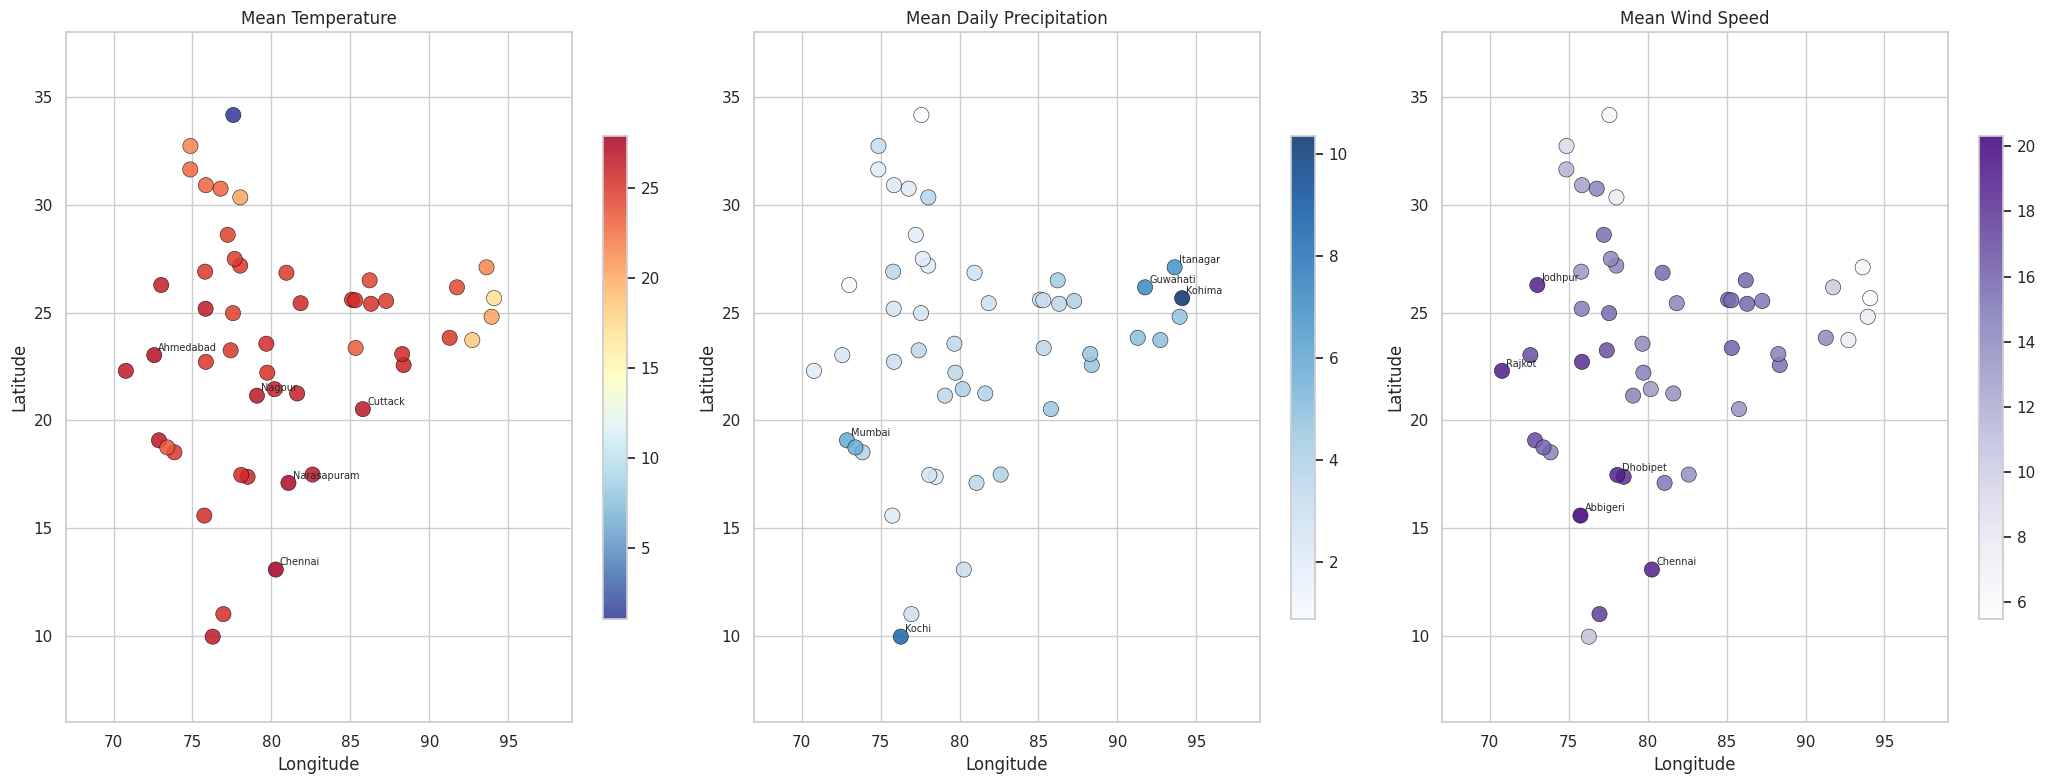

In [11]:
map_targets = [
    ("mean_temp", "Mean Temperature", "RdYlBu_r"),
    ("mean_precip", "Mean Daily Precipitation", "Blues"),
    ("mean_wind_100m", "Mean Wind Speed", "Purples"),
]
map_targets = [item for item in map_targets if item[0] in city_profile]

fig, axes = plt.subplots(1, len(map_targets), figsize=(7 * len(map_targets), 8), squeeze=False)
for ax, (column, label, cmap) in zip(axes.flat, map_targets):
    scatter = ax.scatter(
        city_profile["longitude"], city_profile["latitude"],
        c=city_profile[column], cmap=cmap, s=120, alpha=0.85,
        edgecolors="black", linewidths=0.4
    )
    plt.colorbar(scatter, ax=ax, shrink=0.70)
    for _, row in city_profile.nlargest(5, column).iterrows():
        ax.annotate(row["city_clean"][:12],
                    (row["longitude"], row["latitude"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(67, 99)
    ax.set_ylim(6, 38)

plt.tight_layout()
plt.savefig(SAVE + "spatial_weather_maps.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — Regional weather comparison across India

mean_temp                   annual_precip                         \
              count  mean median  std         count    mean  median    std   
region                                                                       
North             7 19.47  22.87 8.21             7  840.35  795.23 336.68   
Northeast         8 22.26  22.88 3.42             8 2186.11 1780.93 739.80   
East              7 25.00  25.18 1.06             7 1372.57 1321.14 206.10   
Central          11 25.40  25.24 0.70            11 1148.64 1281.53 250.55   
West             10 25.68  25.92 1.09            10 1185.01 1023.50 562.35   
South             7 26.51  26.59 0.94             7 1407.21 1153.16 764.54   

          mean_humidity                   mean_wind_100m                    \
                  count  mean median  std          count  mean median  std   
region                                                                       
North                 7 63.00  65.00 7.16              7 11.00  11.55 3.42   
Northeast             8 79.18  79.12 2.46              8 10.07   8.83 3.92   
East                  7 71.55  71.67 3.27              7 15.23  15.57 0.85   
Central              11 60.63  60.40 3.02             11 14.47  14.14 1.03   
West                 10 61.03  59.84 8.47             10 16.80  16.84 2.30   
South                 7 71.52  71.82 8.12              7 16.02  17.41 3.05   

          mean_cloud                    
               count  mean median  std  
region                                  
North              7 23.19  19.96 6.62  
Northeast          8 40.62  41.23 6.22  
East               7 28.86  28.34 3.29  
Central           11 25.05  26.39 3.58  
West              10 29.12  28.45 8.05  
South              7 39.21  34.54 8.36

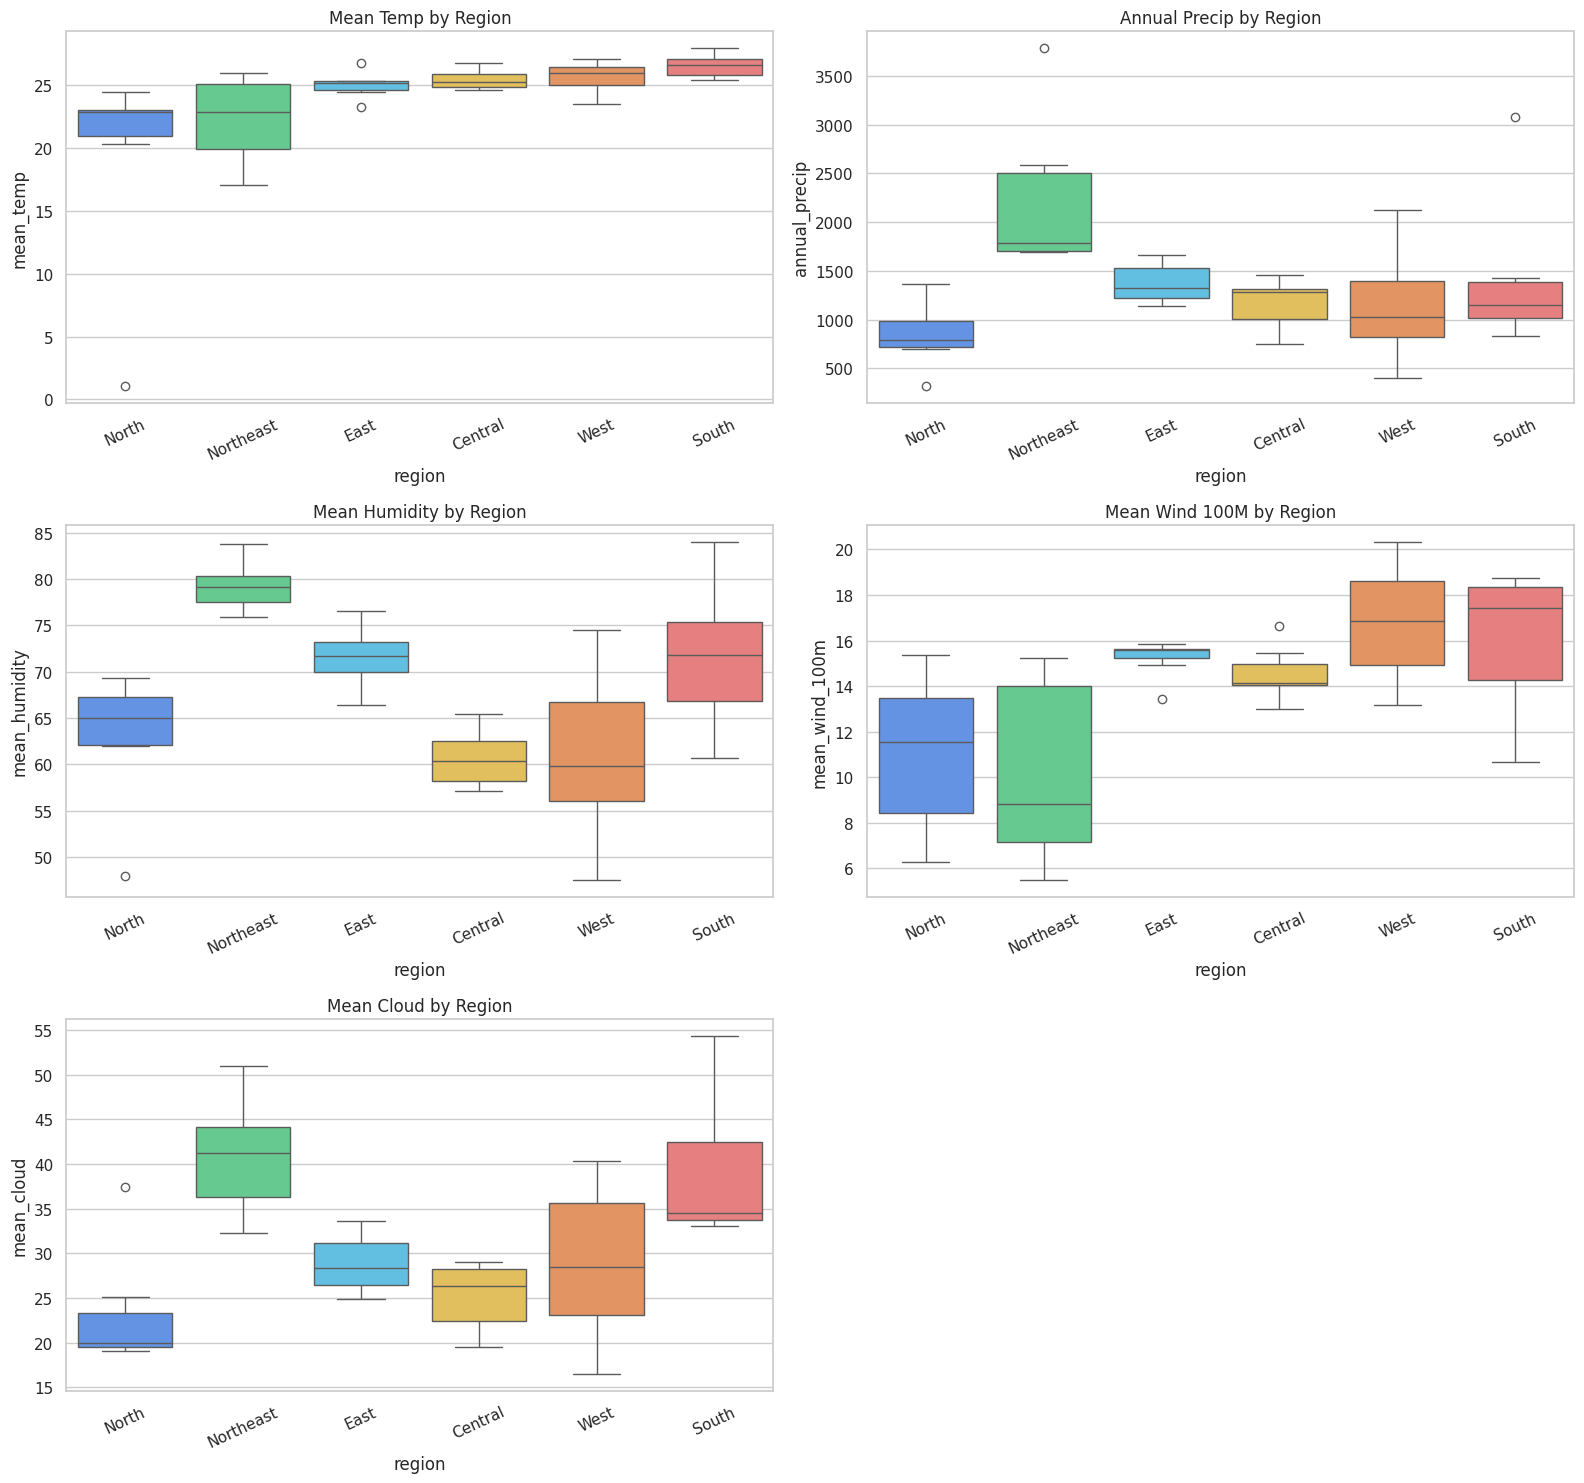

In [12]:
regional_metrics = [c for c in [
    "mean_temp", "annual_precip", "mean_humidity", "mean_wind_100m", "mean_cloud"
] if c in city_profile]

regional_summary = city_profile.groupby("region")[regional_metrics].agg(
    ["count", "mean", "median", "std"]
).reindex([r for r in REGION_ORDER if r in city_profile["region"].unique()])
display(regional_summary)

fig, axes = plt.subplots(int(np.ceil(len(regional_metrics) / 2)), 2,
                         figsize=(16, 5 * int(np.ceil(len(regional_metrics) / 2))), squeeze=False)
for ax, metric in zip(axes.flat, regional_metrics):
    order = [r for r in REGION_ORDER if r in city_profile["region"].unique()]
    sns.boxplot(data=city_profile, x="region", y=metric,
                order=order, palette=REGION_COLORS, ax=ax)
    ax.set_title(metric.replace("_", " ").title() + " by Region")
    ax.tick_params(axis="x", rotation=25)

for ax in axes.flat[len(regional_metrics):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(SAVE + "regional_weather_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

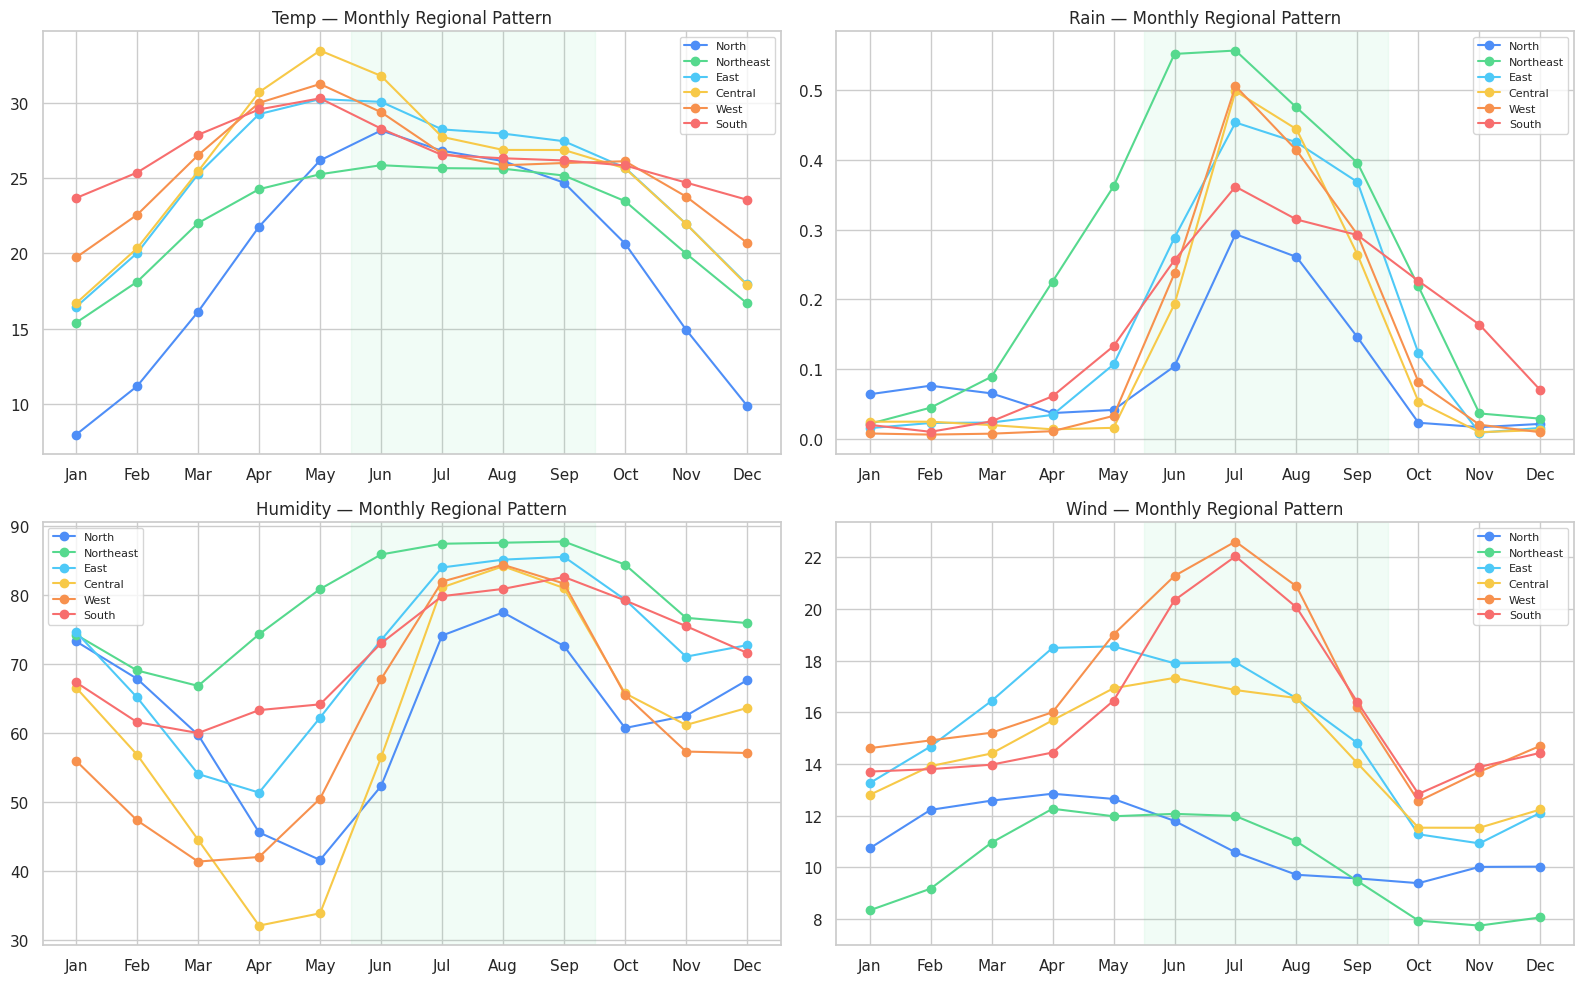

In [13]:
monthly_metrics = [c for c in ["temp", "rain", "humidity", "wind"] if c in region_monthly]
region_monthly_mean = region_monthly.groupby(["region", "month"])[monthly_metrics].mean().reset_index()

fig, axes = plt.subplots(int(np.ceil(len(monthly_metrics) / 2)), 2,
                         figsize=(16, 5 * int(np.ceil(len(monthly_metrics) / 2))), squeeze=False)
for ax, metric in zip(axes.flat, monthly_metrics):
    for region in REGION_ORDER:
        part = region_monthly_mean[region_monthly_mean["region"] == region]
        if not part.empty:
            ax.plot(part["month"], part[metric], marker="o",
                    color=REGION_COLORS[region], label=region)
    ax.axvspan(5.5, 9.5, color="#56d98e", alpha=0.08)
    ax.set_xticks(range(1, 13), MONTHS)
    ax.set_title(metric.replace("_", " ").title() + " — Monthly Regional Pattern")
    ax.legend(fontsize=8)

for ax in axes.flat[len(monthly_metrics):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(SAVE + "monthly_regional_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Peak rainfall month by latitude

,latitude_band,mean_peak_month,cities
0,6-10N,6.00,1
1,10-14N,10.50,2
2,14-18N,7.00,5
3,18-22N,7.14,7
4,22-26N,7.10,20
5,26-30N,7.00,9
6,30-34N,7.00,5
7,34-38N,6.00,1


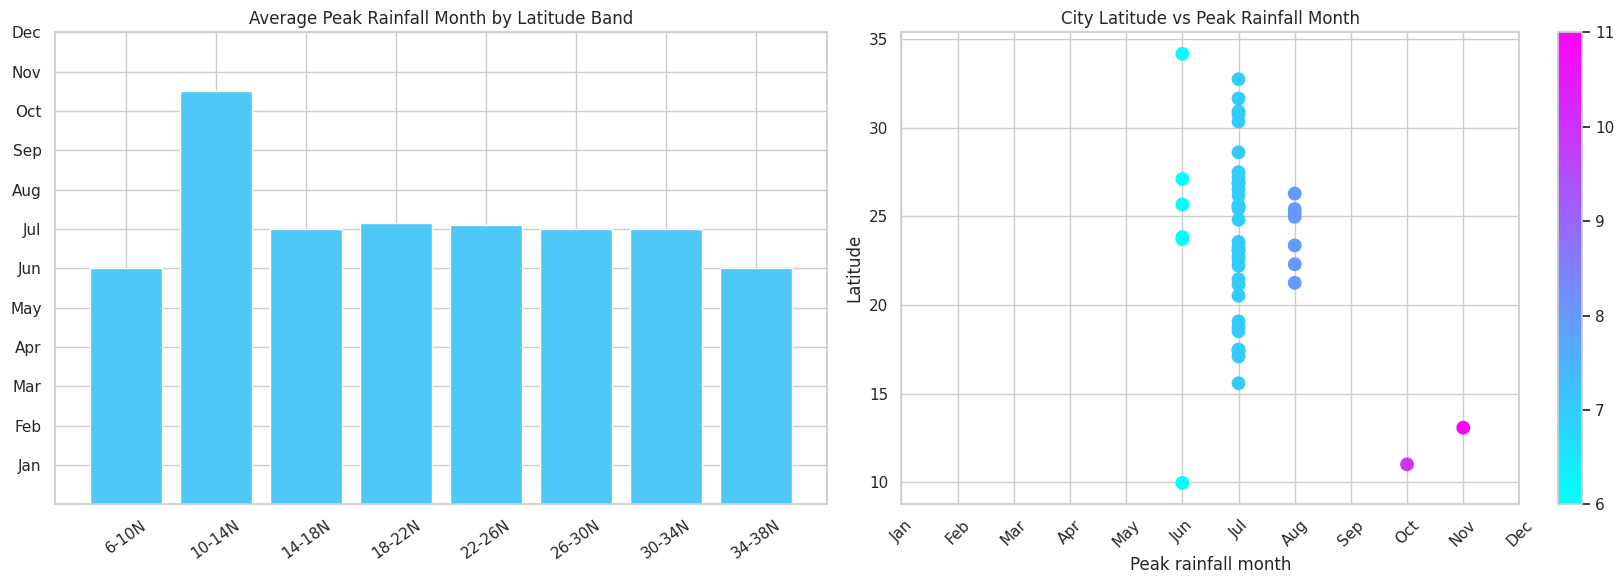

In [14]:
if "rain" in region_monthly:
    peak_index = region_monthly.groupby("city_clean")["rain"].idxmax()
    peak_rain = region_monthly.loc[peak_index, ["city_clean", "latitude", "month", "rain"]].dropna()

    latitude_edges = np.linspace(6, 38, 9)
    latitude_labels = [f"{int(latitude_edges[i])}-{int(latitude_edges[i+1])}N"
                       for i in range(len(latitude_edges) - 1)]
    peak_rain["latitude_band"] = pd.cut(
        peak_rain["latitude"], bins=latitude_edges,
        labels=latitude_labels, include_lowest=True
    )

    latitude_peak = (peak_rain.groupby("latitude_band", observed=True)
                     .agg(mean_peak_month=("month", "mean"), cities=("city_clean", "count"))
                     .reset_index())
    display(latitude_peak)

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    axes[0].bar(latitude_peak["latitude_band"].astype(str),
                latitude_peak["mean_peak_month"], color="#4ec9f7")
    axes[0].set_yticks(range(1, 13), MONTHS)
    axes[0].set_title("Average Peak Rainfall Month by Latitude Band")
    axes[0].tick_params(axis="x", rotation=35)

    scatter = axes[1].scatter(peak_rain["month"], peak_rain["latitude"],
                              c=peak_rain["month"], cmap="cool", s=80)
    axes[1].set_xticks(range(1, 13), MONTHS, rotation=45)
    axes[1].set_xlabel("Peak rainfall month")
    axes[1].set_ylabel("Latitude")
    axes[1].set_title("City Latitude vs Peak Rainfall Month")
    plt.colorbar(scatter, ax=axes[1])
    plt.tight_layout()
    plt.savefig(SAVE + "rainfall_by_latitude.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    peak_rain = pd.DataFrame()
    latitude_peak = pd.DataFrame()
    print("Rainfall column was unavailable, so this analysis was skipped.")

## Step 9 — Validate spatial trends

In [15]:
spatial_tests = []
for coordinate, metric in [
    ("latitude", "mean_temp"),
    ("latitude", "annual_precip"),
    ("longitude", "mean_temp"),
    ("longitude", "annual_precip"),
    ("elevation", "mean_temp"),
]:
    if metric not in city_profile:
        continue
    part = city_profile[[coordinate, metric]].dropna()
    if len(part) >= 5 and part[coordinate].nunique() > 1:
        correlation = part[coordinate].corr(part[metric])
        spatial_tests.append({
            "coordinate": coordinate, "weather_metric": metric,
            "cities_used": len(part), "correlation": correlation,
            "strength": "strong" if abs(correlation) >= 0.70 else
                        "moderate" if abs(correlation) >= 0.40 else "weak"
        })

spatial_trend_report = pd.DataFrame(spatial_tests)
display(spatial_trend_report)

,coordinate,weather_metric,cities_used,correlation,strength
0,latitude,mean_temp,50,-0.51,moderate
1,latitude,annual_precip,50,-0.26,weak
2,longitude,mean_temp,50,-0.17,weak
3,longitude,annual_precip,50,0.55,moderate


## Step 10 — Identify anomalous cities

In [16]:
anomaly_metrics = [c for c in [
    "mean_temp", "mean_precip", "mean_wind_100m", "mean_humidity", "mean_cloud"
] if c in city_profile]

flag_table = pd.DataFrame(index=city_profile.index)
for metric in anomaly_metrics:
    median = city_profile[metric].median()
    mad = (city_profile[metric] - median).abs().median()
    robust_z = (0.6745 * (city_profile[metric] - median) / mad
                if mad > 0 else pd.Series(0, index=city_profile.index))
    city_profile[metric + "_robust_z"] = robust_z
    flag_table[metric] = robust_z.abs() > 3.5

city_profile["anomaly_count"] = flag_table.sum(axis=1)
city_profile["anomaly_flag"] = np.where(city_profile["anomaly_count"] > 0, "REVIEW", "OK")

anomaly_report = city_profile.loc[
    city_profile["anomaly_flag"] == "REVIEW",
    ["city_clean", "region", "anomaly_count"] + anomaly_metrics
].sort_values("anomaly_count", ascending=False)

display(anomaly_report)
print("Cities with anomalous summaries:", len(anomaly_report))

,city_clean,region,anomaly_count,mean_temp,mean_precip,mean_wind_100m,mean_humidity,mean_cloud
21,Kohima,Northeast,3,17.04,10.35,5.50,83.80,50.93
3,Aizawl,Northeast,2,18.40,4.84,7.35,80.49,43.87
24,Leh,North,2,1.09,0.88,6.29,47.96,37.44
16,Itanagar,Northeast,1,21.57,6.77,6.52,79.66,44.80
14,Imphal,Northeast,1,20.37,4.69,7.44,77.71,41.79


Cities with anomalous summaries: 5


## Step 11 — Final city-quality report

In [17]:
city_profile["final_status"] = np.select(
    [
        city_profile["sparse_flag"].eq("REVIEW") & city_profile["anomaly_flag"].eq("REVIEW"),
        city_profile["sparse_flag"].eq("REVIEW"),
        city_profile["anomaly_flag"].eq("REVIEW"),
    ],
    ["REVIEW DATA + WEATHER", "REVIEW DATA", "REVIEW WEATHER"],
    default="OK"
)

final_report = city_profile[[
    "city_clean", "state", "region", "latitude", "longitude",
    "row_count", "coverage_pct", "years_covered", "mean_missing_pct",
    "anomaly_count", "final_status"
]].sort_values(["final_status", "city_clean"])

display(final_report)
print(final_report["final_status"].value_counts())

,city_clean,state,region,latitude,longitude,row_count,coverage_pct,years_covered,mean_missing_pct,anomaly_count,final_status
35,Abbigeri,NaN,West,15.59,75.75,5164,100.00,15,0.00,0,OK
0,Agartala,NaN,Northeast,23.83,91.28,5164,100.00,15,0.00,0,OK
1,Agra,NaN,Central,27.18,78.02,5164,100.00,15,0.00,0,OK
2,Ahmedabad,NaN,West,23.03,72.58,5164,100.00,15,0.00,0,OK
4,Amritsar,NaN,North,31.64,74.86,5164,100.00,15,0.00,0,OK
36,Badarwas,NaN,Central,24.98,77.56,5164,100.00,15,0.00,0,OK
37,Bhagatpur,NaN,East,25.41,86.31,5164,100.00,15,0.00,0,OK
5,Bhopal,NaN,Central,23.25,77.42,5164,100.00,15,0.00,0,OK
6,Chandigarh,NaN,North,30.75,76.78,5164,100.00,15,0.00,0,OK
38,Chatra Gobraura,NaN,East,26.50,86.22,5164,100.00,15,0.00,0,OK


final_status
OK                45
REVIEW WEATHER     5
Name: count, dtype: int64


## Step 12 — Export results

In [ ]:
selected_files[["city", "state", "region", "latitude", "longitude", "file"]].to_csv(
    SAVE + "selected_50_cities.csv", index=False
)
city_profile.to_csv(SAVE + "city_profile.csv", index=False)
region_monthly.to_csv(SAVE + "regional_monthly_profile.csv", index=False)
coverage_report.to_csv(SAVE + "city_coverage_report.csv", index=False)
regional_summary.to_csv(SAVE + "regional_summary.csv")
spatial_trend_report.to_csv(SAVE + "spatial_trend_report.csv", index=False)
anomaly_report.to_csv(SAVE + "anomalous_cities.csv", index=False)
final_report.to_csv(SAVE + "final_city_quality_report.csv", index=False)
load_log.to_csv(SAVE + "load_log.csv", index=False)

if not peak_rain.empty:
    peak_rain.to_csv(SAVE + "peak_rainfall_month_by_city.csv", index=False)

print("All results saved in:", SAVE)
print("Download them from the Kaggle Output panel after execution.")

## Interpretation notes

- The metadata CSV supplies coordinates; hourly city files supply weather measurements.
- Regional assignments use state first and coordinate rules only when state is unavailable.
- Coverage below 90%, fewer than 10 years, excessive missing values, or duplicate timestamps causes a data-review flag.
- Robust anomaly scores above 3.5 indicate a city that should be reviewed, not automatically removed.
- Correlation describes spatial association and does not prove causation.